In [ ]:
# Install required packages
!pip install -q transformers torch openpyxl scikit-learn pandas numpy matplotlib seaborn wordcloud

# Uninstall and reinstall NLTK to address potential corruption
!pip uninstall -y nltk
!pip install -q nltk

# Force site package reload to resolve potential NLTK import issues
import site; site.main()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

# Deep Learning imports
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

# NLTK for text preprocessing - only import nltk here initially
import nltk

import warnings
warnings.filterwarnings('ignore')

print("✅ Core libraries imported successfully! Preparing NLTK...")

# Download NLTK resources and import specific components
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to fix LookupError

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("✅ NLTK resources downloaded and modules imported!")

Found existing installation: nltk 3.9.2
Uninstalling nltk-3.9.2:
  Successfully uninstalled nltk-3.9.2
✅ Core libraries imported successfully! Preparing NLTK...
✅ NLTK resources downloaded and modules imported!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Upload file from your computer
try:
    df = pd.read_csv('Shopee_Reviews_Cleaned and Manually Labelled.csv')
    print("✅ Data Loaded Successfully!")
except FileNotFoundError:
    print("❌ Error: 'Shopee_Reviews_Cleaned and Manually Labelled.csv' not found. Please upload it.")
print(df.head())

✅ Data Loaded Successfully!
       Date  Rating                                             Review  \
0  1/2/2026       1  kedekut syiling emas bila digunakan untuk pemb...   
1  1/2/2026       5  I personally think that this is the best app I...   
2  1/2/2026       5                                            terbaik   
3  1/2/2026       5                          Hope best services thanks   
4  1/2/2026       5                                                 ok   

                    User                                  Translated_Review  \
0             Mohd Fariq  being stingy with gold coins when used to purc...   
1  likchan622 likchan622  I personally think that this is the best app I...   
2          Hisham Sabdin                                           the best   
3               Raine WM                          Hope best services thanks   
4          Aliff Syazwan                                                 ok   

  Manually_Labelled_Sentiment  
0                   

In [ ]:
print(df['Manually_Labelled_Sentiment'].value_counts(dropna=False))


Manually_Labelled_Sentiment
Positive    1327
Negative    1315
Neutral      151
Name: count, dtype: int64



DATASET INFORMATION

Column names: ['Date', 'Rating', 'Review', 'User', 'Translated_Review', 'Manually_Labelled_Sentiment']

Data types:
Date                           object
Rating                          int64
Review                         object
User                           object
Translated_Review              object
Manually_Labelled_Sentiment    object
dtype: object

Missing values:
Date                           0
Rating                         0
Review                         0
User                           0
Translated_Review              0
Manually_Labelled_Sentiment    0
dtype: int64

⚙️ Configuration:
   Text column: 'Translated_Review'
   Sentiment column: 'Manually_Labelled_Sentiment'

💡 If these are incorrect, update TEXT_COLUMN and SENTIMENT_COLUMN variables above

🔄 Standardizing sentiment labels...

📈 Sentiment Distribution:
Manually_Labelled_Sentiment
Positive    1327
Negative    1315
Neutral      151
Name: count, dtype: int64


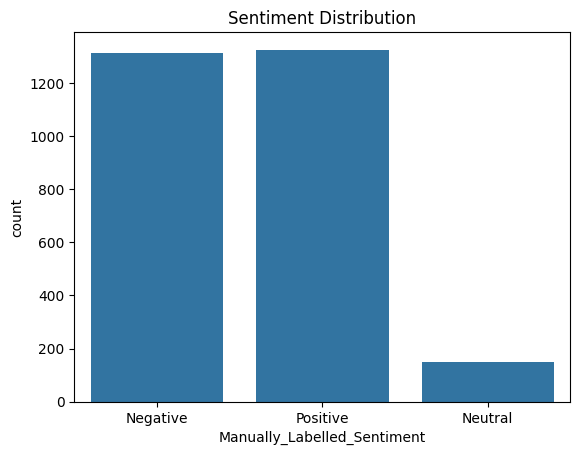


🔄 Cleaning text data...
✅ Text cleaning complete!
   Dataset shape after cleaning: (2793, 7)


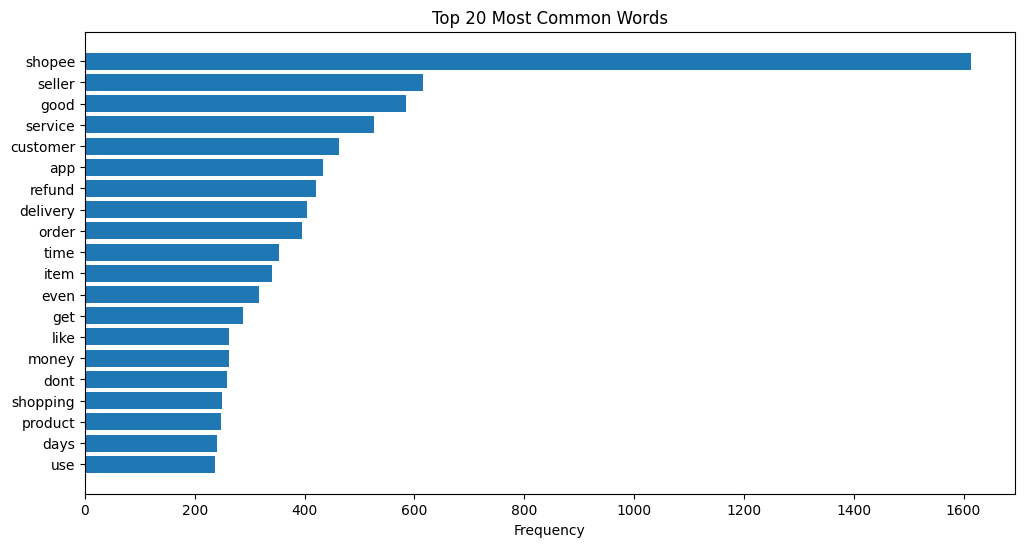

In [ ]:
print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ⚠️ CONFIGURE THESE VARIABLES BASED ON YOUR DATASET
TEXT_COLUMN = 'Translated_Review'  # Change this to your text column name
SENTIMENT_COLUMN = 'Manually_Labelled_Sentiment'  # Change this to your sentiment column name

print(f"\n⚙️ Configuration:")
print(f"   Text column: '{TEXT_COLUMN}'")
print(f"   Sentiment column: '{SENTIMENT_COLUMN}'")
print(f"\n💡 If these are incorrect, update TEXT_COLUMN and SENTIMENT_COLUMN variables above")

# Standardize sentiment labels
print("\n🔄 Standardizing sentiment labels...")
df[SENTIMENT_COLUMN] = df[SENTIMENT_COLUMN].replace({'Nutral': 'Neutral', 'positive': 'Positive'})

# Check sentiment distribution
print(f"\n📈 Sentiment Distribution:")
print(df[SENTIMENT_COLUMN].value_counts())
sns.countplot(data=df, x=SENTIMENT_COLUMN)
plt.title('Sentiment Distribution')
plt.savefig('sentiment_distribution_plot.png') # Save plot
plt.show()

# ============================================================================
# STEP 4: DATA PREPROCESSING
# ============================================================================

# Add NLTK imports here to resolve NameError
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text(text):
    """Clean and preprocess text data"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user mentions and hashtags
    text = re.sub(r'\@\w+|#', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

def remove_stopwords(text):
    """Remove stopwords from text"""
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word not in stop_words]
    return ' '.join(filtered_text)

print("\n🔄 Cleaning text data...")

# Apply cleaning
df['cleaned_text'] = df[TEXT_COLUMN].apply(clean_text)
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

# Remove empty rows
df = df[df['cleaned_text'].str.strip() != '']

print(f"✅ Text cleaning complete!")
print(f"   Dataset shape after cleaning: {df.shape}")

# Visualize most common words
all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words).most_common(20)

plt.figure(figsize=(12, 6))
words, counts = zip(*word_freq)
plt.barh(words, counts)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.gca().invert_yaxis()
plt.savefig('top_20_words_plot.png') # Save plot
plt.show()

In [ ]:
# ============================================================================
# STEP 5: PREPARE DATA FOR MODELING
# ============================================================================

from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df[SENTIMENT_COLUMN])

# Map original labels to encoded values for later use
sentiment_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\n✅ Sentiment labels encoded: {sentiment_mapping}")

# Split data into training and testing sets
X = df['cleaned_text']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Data split into training and testing sets.")
print(f"   Training set shape: {X_train.shape}")
print(f"   Testing set shape: {X_test.shape}")

# Vectorize text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for efficiency
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\n✅ Text data vectorized using TF-IDF.")
print(f"   TF-IDF training features shape: {X_train_tfidf.shape}")
print(f"   TF-IDF testing features shape: {X_test_tfidf.shape}")


✅ Sentiment labels encoded: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

✅ Data split into training and testing sets.
   Training set shape: (2234,)
   Testing set shape: (559,)

✅ Text data vectorized using TF-IDF.
   TF-IDF training features shape: (2234, 5000)
   TF-IDF testing features shape: (559, 5000)


In [ ]:
# Map sentiment labels to numerical values if needed
sentiment_mapping = {label: idx for idx, label in enumerate(df[SENTIMENT_COLUMN].unique())}
df['label'] = df[SENTIMENT_COLUMN].map(sentiment_mapping)

print(f"\n🏷️ Sentiment Label Mapping:")
for sentiment, label in sentiment_mapping.items():
    print(f"   {sentiment} → {label}")

# Split data
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✂️ Data Split:")
print(f"   Training samples: {len(X_train)}")
print(f"   Testing samples: {len(X_test)}")



🏷️ Sentiment Label Mapping:
   Negative → 0
   Positive → 1
   Neutral → 2

✂️ Data Split:
   Training samples: 2234
   Testing samples: 559



MODEL 1: LOGISTIC REGRESSION

🔄 Training Logistic Regression...
  ✓ Model trained

📊 Logistic Regression Results:
Accuracy: 0.8730 (87.30%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.92      0.91       263
    Positive       0.95      0.86      0.90       266
     Neutral       0.33      0.50      0.39        30

    accuracy                           0.87       559
   macro avg       0.72      0.76      0.74       559
weighted avg       0.89      0.87      0.88       559


✓ Confusion matrix saved: lr_confusion_matrix.png


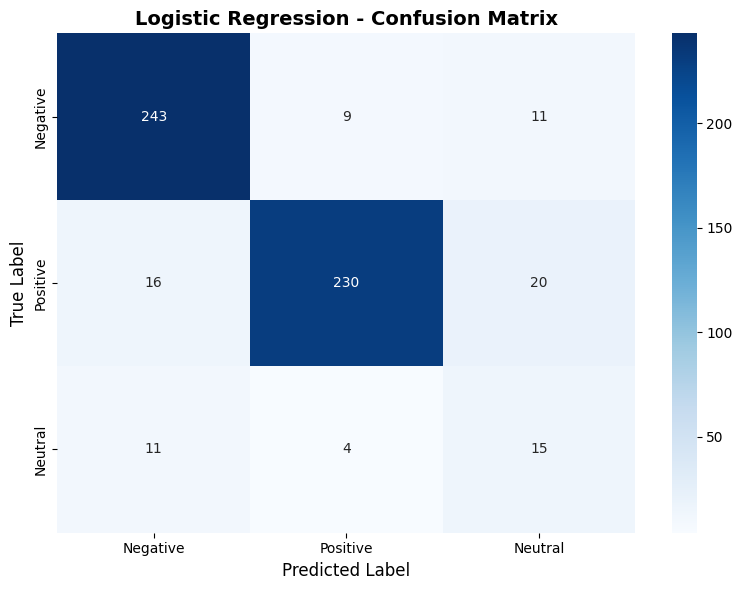

In [ ]:
# ========================================
# STEP 8: MODEL 1 - LOGISTIC REGRESSION
# ========================================
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*80)

# Ensure X_train and X_test are vectorized using the existing tfidf_vectorizer
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\n🔄 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)
lr_model.fit(X_train_tfidf, y_train) # Use TF-IDF vectorized data
print("  ✓ Model trained")

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf) # Use TF-IDF vectorized data

# Evaluation
print("\n📊 Logistic Regression Results:")
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

# Dynamically create target names based on the sentiment_mapping order
sorted_sentiment_labels = sorted(sentiment_mapping, key=sentiment_mapping.get)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                          target_names=sorted_sentiment_labels,
                          zero_division=0))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[sentiment_mapping[label] for label in sorted_sentiment_labels])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted_sentiment_labels,
            yticklabels=sorted_sentiment_labels)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix saved: lr_confusion_matrix.png")
plt.show()


MODEL 3: DEEP LEARNING (DistilBERT)

📥 Loading tokenizer and model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



🔧 Preparing datasets...

🔄 Training DistilBERT (this may take a few minutes)...
   Epochs: 3
   Batch size: 16
   Training samples: 2234


Epoch,Training Loss,Validation Loss
1,0.424783,0.317885
2,0.266743,0.281069
3,0.185227,0.307892


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



🔮 Making predictions on test set...



📊 Deep Learning (DistilBERT) Results:
Accuracy: 0.9070

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.96      0.93       263
    Positive       0.92      0.92      0.92       266
     Neutral       0.57      0.27      0.36        30

    accuracy                           0.91       559
   macro avg       0.80      0.72      0.74       559
weighted avg       0.90      0.91      0.90       559



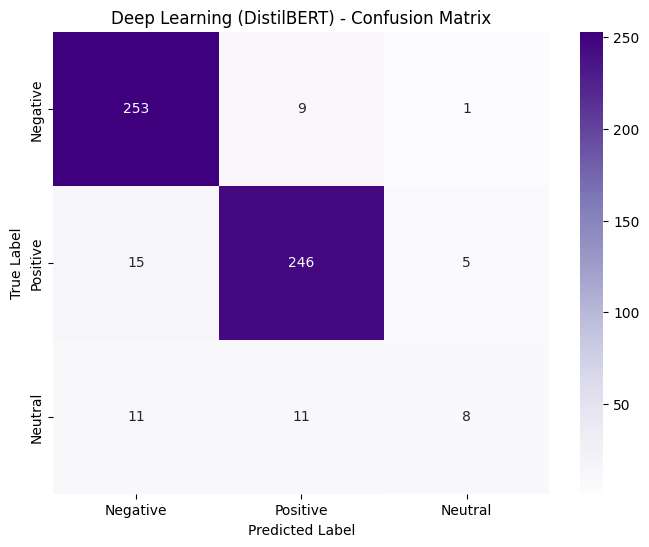


✅ Deep Learning model training complete!


In [ ]:

print("\n" + "="*80)
print("MODEL 3: DEEP LEARNING (DistilBERT)")
print("="*80)

# Prepare data for transformers
from torch.utils.data import Dataset
import torch

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer and model
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = 'distilbert-base-uncased'
print(f"\n📥 Loading tokenizer and model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(sentiment_mapping)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# Create datasets
print("\n🔧 Preparing datasets...")
train_dataset = SentimentDataset(X_train.reset_index(drop=True),
                                y_train.reset_index(drop=True),
                                tokenizer)
test_dataset = SentimentDataset(X_test.reset_index(drop=True),
                               y_test.reset_index(drop=True),
                               tokenizer)

# FIXED: Training arguments with proper syntax for latest transformers version
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",  # FIXED: Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    report_to="none"  # Disable wandb/tensorboard logging
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print("\n🔄 Training DistilBERT (this may take a few minutes)...")
print("   Epochs: 3")
print("   Batch size: 16")
print("   Training samples:", len(train_dataset))

# Train the model
trainer.train()

# Predictions
print("\n🔮 Making predictions on test set...")
predictions = trainer.predict(test_dataset)
y_pred_dl = np.argmax(predictions.predictions, axis=1)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n📊 Deep Learning (DistilBERT) Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dl):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dl,
                          target_names=[str(k) for k in sentiment_mapping.keys()]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_dl = confusion_matrix(y_test, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples',
            xticklabels=sentiment_mapping.keys(),
            yticklabels=sentiment_mapping.keys())
plt.title('Deep Learning (DistilBERT) - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('distilbert_confusion_matrix.png') # Save plot
plt.show()

print("\n✅ Deep Learning model training complete!")


MODEL 2: NAIVE BAYES

🔄 Training Naive Bayes...

📊 Naive Bayes Results:
Accuracy: 0.8748

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.92      0.91       263
    Positive       0.86      0.93      0.90       266
     Neutral       0.00      0.00      0.00        30

    accuracy                           0.87       559
   macro avg       0.59      0.62      0.60       559
weighted avg       0.83      0.87      0.85       559



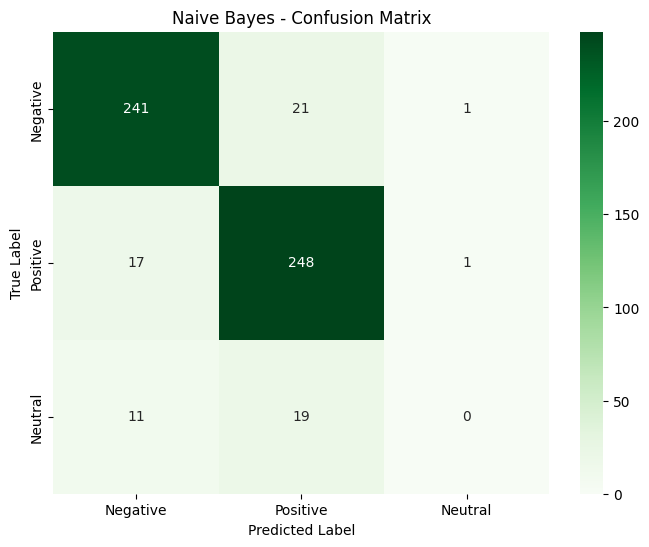

In [ ]:
# ============================================================================
# STEP 7: MODEL 2 - NAIVE BAYES
# ============================================================================

print("\n" + "="*80)
print("MODEL 2: NAIVE BAYES")
print("="*80)

# Count Vectorization (better for Naive Bayes)
count_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

print("\n🔄 Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_count, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_count)

# Evaluation
print("\n📊 Naive Bayes Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb,
                          target_names=[str(k) for k in sentiment_mapping.keys()]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=sentiment_mapping.keys(),
            yticklabels=sentiment_mapping.keys())
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('nb_confusion_matrix.png') # Save plot
plt.show()


MODEL COMPARISON

📊 Accuracy Comparison:
   Logistic Regression : 0.8730
   Naive Bayes         : 0.8748
   DistilBERT          : 0.9070


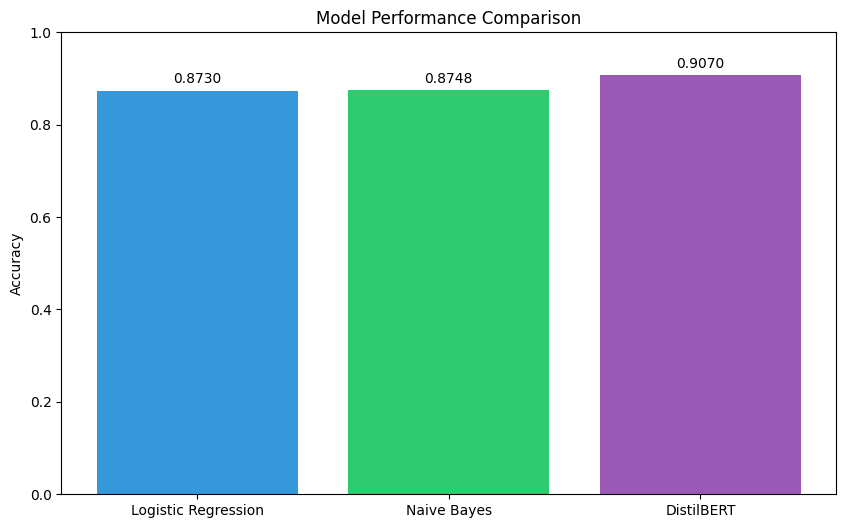


🏆 Best Model: DistilBERT with accuracy 0.9070


In [ ]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Calculate metrics for all models
models_performance = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'predictions': y_pred_lr
    },
    'Naive Bayes': {
        'accuracy': accuracy_score(y_test, y_pred_nb),
        'predictions': y_pred_nb
    },
    'DistilBERT': {
        'accuracy': accuracy_score(y_test, y_pred_dl),
        'predictions': y_pred_dl
    }
}

# Print comparison
print("\n📊 Accuracy Comparison:")
for model_name, metrics in models_performance.items():
    print(f"   {model_name:20s}: {metrics['accuracy']:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
models = list(models_performance.keys())
accuracies = [models_performance[m]['accuracy'] for m in models]

plt.bar(models, accuracies, color=['#3498db', '#2ecc71', '#9b59b6'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
plt.savefig('model_comparison_chart.png') # Save plot
plt.show()

# Best model
best_model_name = max(models_performance, key=lambda x: models_performance[x]['accuracy'])
print(f"\n🏆 Best Model: {best_model_name} with accuracy {models_performance[best_model_name]['accuracy']:.4f}")

In [ ]:
# ============================================================================
# STEP 10: PREDICTION FUNCTION FOR NEW DATA
# ============================================================================

def predict_sentiment(text, model_choice='best'):
    """
    Predict sentiment for new text

    Args:
        text: Input text string
        model_choice: 'lr', 'nb', 'dl', or 'best'
    """
    # Clean the text
    cleaned = clean_text(text)
    cleaned = remove_stopwords(cleaned)

    if model_choice == 'best':
        model_choice = best_model_name.lower().replace(' ', '_')

    if model_choice == 'logistic_regression' or model_choice == 'lr':
        text_tfidf = tfidf.transform([cleaned])
        pred = lr_model.predict(text_tfidf)[0]
    elif model_choice == 'naive_bayes' or model_choice == 'nb':
        text_count = count_vec.transform([cleaned])
        pred = nb_model.predict(text_count)[0]
    elif model_choice == 'distilbert' or model_choice == 'dl':
        encoding = tokenizer(cleaned, return_tensors='pt',
                           max_length=128, truncation=True, padding='max_length')
        model.eval()
        with torch.no_grad():
            outputs = model(**encoding)
            pred = torch.argmax(outputs.logits, dim=1).item()

    # Get sentiment label
    reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
    sentiment = reverse_mapping[pred]

    return sentiment

# Example predictions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS")
print("="*80)

test_texts = [
    "This is absolutely amazing! I love it!",
    "Terrible experience, very disappointed.",
    "It's okay, nothing special."
]

for text in test_texts:
    sentiment = predict_sentiment(text, model_choice='best')
    print(f"\nText: '{text}'")
    print(f"Predicted Sentiment: {sentiment}")



EXAMPLE PREDICTIONS

Text: 'This is absolutely amazing! I love it!'
Predicted Sentiment: Positive

Text: 'Terrible experience, very disappointed.'
Predicted Sentiment: Positive

Text: 'It's okay, nothing special.'
Predicted Sentiment: Positive


In [ ]:
# ============================================================================
# STEP 11: SAVE MODELS (OPTIONAL)
# ============================================================================

print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

import pickle

# Save traditional ML models
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('count_vectorizer.pkl', 'wb') as f:
    pickle.dump(count_vec, f)

# Save deep learning model
model.save_pretrained('./distilbert_sentiment_model')
tokenizer.save_pretrained('./distilbert_sentiment_model')

print("✅ All models saved successfully!")
print("\nSaved files:")
print("   - logistic_regression_model.pkl")
print("   - naive_bayes_model.pkl")
print("   - tfidf_vectorizer.pkl")
print("   - count_vectorizer.pkl")
print("   - ./distilbert_sentiment_model/")

print("\n" + "="*80)
print("✨ ANALYSIS COMPLETE! ✨")
print("="*80)


SAVING MODELS


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All models saved successfully!

Saved files:
   - logistic_regression_model.pkl
   - naive_bayes_model.pkl
   - tfidf_vectorizer.pkl
   - count_vectorizer.pkl
   - ./distilbert_sentiment_model/

✨ ANALYSIS COMPLETE! ✨
